## Calculate Movement

In [1]:
import matplotlib.pyplot as plt
from helper.loader.evaulation_area import EvaluationArea
from helper.loader.Read_Dataset import read_participant_data, get_dataset_paths
from helper.loader.create_dataframe import CreateDataset

## Daten holen

In [2]:
p1_id = ['participant_1','participant_2','participant_3', 'participant_4', 'participant_5', 'participant_6', 'participant_7', 'participant_8','participant_9','participant_10'] 
data_paths_p1 = get_dataset_paths(participants_list=p1_id, long_data=True, forward_data=True, back_data=True)

Processing participants: ['participant_1', 'participant_2', 'participant_3', 'participant_4', 'participant_5', 'participant_6', 'participant_7', 'participant_8', 'participant_9', 'participant_10']


In [3]:
long_area_eval_area = EvaluationArea(area_beginning=(-60, -40), area_end=(-10, -10))
dict_eval_areas = {
    "long": None
}

CD_p1 = CreateDataset(
    dict_paths=data_paths_p1, 
    eval_areas=dict_eval_areas,
    eval_participants=p1_id,
    android_included=True, 
    holo_included=True
)

res_dict = CD_p1.get_eval_dataframes(long_data=True, forward_data=True, back_data=True, whole_way_back=True, whole_way_fwd=True, whole_way_long=True, test_area=True)


Checking/Creating resized images (256x256)...
Small images found. Skipping resize.
--- Synchronisations-Ergebnis ---
Gesamtanzahl Zeilen (Holo-Basis): 5562
Video-Matches gefunden:  5527 (99.37%)
Sensor-Matches gefunden: 5108 (91.84%)
Sensor Ø Zeitversatz: 7.79 ms
Sensor Max Zeitversatz: 17.00 ms
--- Synchronisations-Ergebnis ---
Gesamtanzahl Zeilen (Holo-Basis): 4809
Video-Matches gefunden:  4770 (99.19%)
Sensor-Matches gefunden: 4518 (93.95%)
Sensor Ø Zeitversatz: 7.17 ms
Sensor Max Zeitversatz: 17.00 ms
--- Synchronisations-Ergebnis ---
Gesamtanzahl Zeilen (Holo-Basis): 4736
Video-Matches gefunden:  4705 (99.35%)
Sensor-Matches gefunden: 4337 (91.58%)
Sensor Ø Zeitversatz: 8.07 ms
Sensor Max Zeitversatz: 17.00 ms
--- Synchronisations-Ergebnis ---
Gesamtanzahl Zeilen (Holo-Basis): 4297
Video-Matches gefunden:  4258 (99.09%)
Sensor-Matches gefunden: 3913 (91.06%)
Sensor Ø Zeitversatz: 8.42 ms
Sensor Max Zeitversatz: 17.00 ms
--- Synchronisations-Ergebnis ---
Gesamtanzahl Zeilen (Holo-B

In [4]:
ls_long = res_dict['eval_long_way']
ls_back = res_dict['eval_back_way']
ls_forwad = res_dict['eval_forward_way']

In [6]:
len(ls_long), len(ls_back), len(ls_forwad)

(7, 9, 10)

In [7]:
for id, group in enumerate([ls_long, ls_back, ls_forwad]):
    for identification,df in enumerate(group):
        print(f"merged_data/{id}/{identification}.csv")
        df.to_csv(f"Dataset/merged_data/{id}/{identification}.csv")

merged_data/0/0.csv
merged_data/0/1.csv
merged_data/0/2.csv
merged_data/0/3.csv
merged_data/0/4.csv
merged_data/0/5.csv
merged_data/0/6.csv
merged_data/1/0.csv
merged_data/1/1.csv
merged_data/1/2.csv
merged_data/1/3.csv
merged_data/1/4.csv
merged_data/1/5.csv
merged_data/1/6.csv
merged_data/1/7.csv
merged_data/1/8.csv
merged_data/2/0.csv
merged_data/2/1.csv
merged_data/2/2.csv
merged_data/2/3.csv
merged_data/2/4.csv
merged_data/2/5.csv
merged_data/2/6.csv
merged_data/2/7.csv
merged_data/2/8.csv
merged_data/2/9.csv


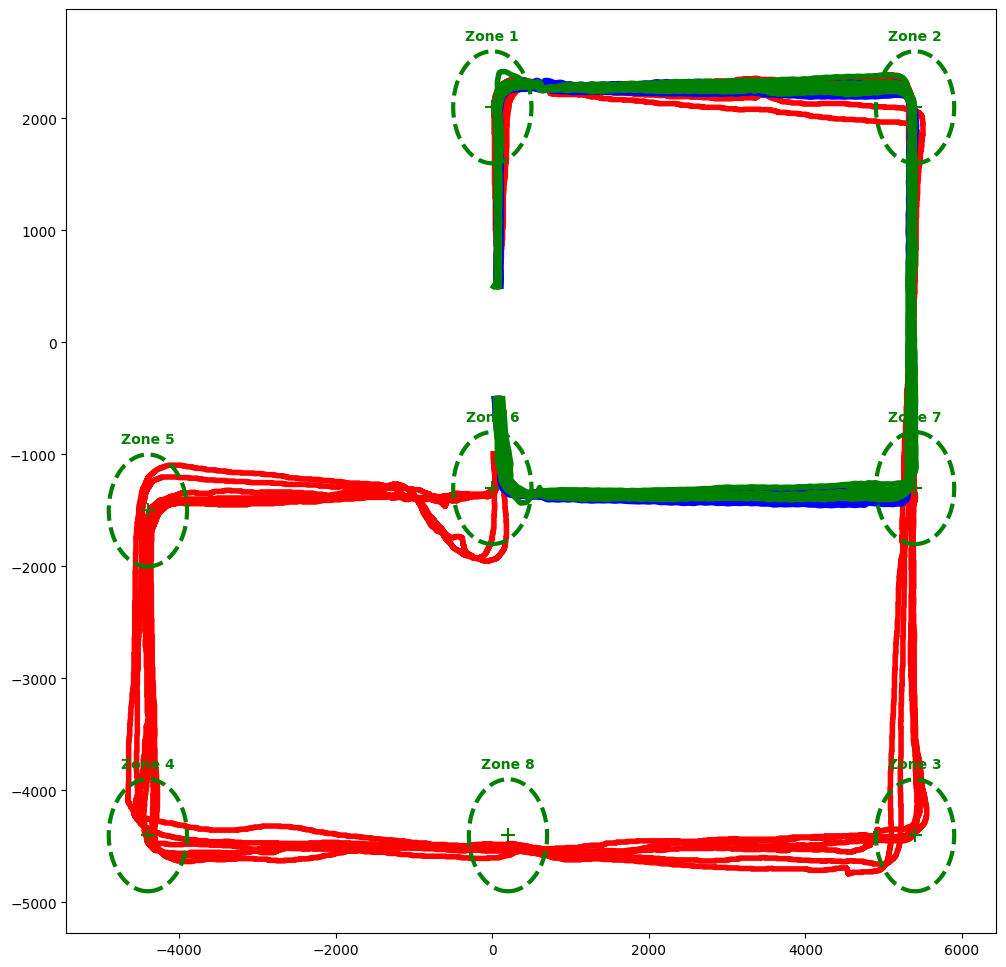

In [5]:
import matplotlib.patches as patches # Wichtig für die Kreise

my_corners = [
    (0, 2100), # Unten Links
    (5400, 2100),  # Unten Rechts
    (5400, -4400),   # Oben Rechts
    (-4400, -4400),    # Oben Mitte (Eingang Einkerbung)
    (-4400, -1500),   # Mitte (Unten in Einkerbung)
    (0, -1300),  # (Duplikat/Extra Punkt in Einkerbung?)
    (5400, -1300),  # Oben Links (Start/Ende Einkerbung)
    (200, -4400)
]
color_ls = ["red","blue","green"]
fig, ax = plt.subplots(figsize=(12, 12))
for id,ls in enumerate([ls_long, ls_back, ls_forwad]):
    for df in ls:
        ax.plot(df['x_new'], df['y_new'], color=color_ls[id], linewidth=4, zorder=1, label='Pfad')

for i, (cx, cy) in enumerate(my_corners):
    # Kreis definieren: Radius 300 (anpassbar), Grün, Gestrichelt
    circle = patches.Circle((cx, cy), radius=500, fill=False, edgecolor='green', linewidth=3, linestyle='--', zorder=2)
    ax.add_patch(circle)
    
    # Text-Label dazu (leicht versetzt)
    ax.text(cx, cy + 600, f"Zone {i+1}", color='green', fontsize=10, fontweight='bold', ha='center', zorder=4)
    
    # Optional: Kleines Kreuz in der Mitte des Kreises, damit man das Zentrum sieht
    ax.scatter(cx, cy, color='green', marker='+', s=100, zorder=3)


plt.show()


Um zu wissen, wann eine Person in einer Zone ist, wird im folgende analysiert. Wie mittels optical flow die steps predicted werden koennen

## Data Preperation

wir haben 3 strecken long, back forward.
wir muessen die bewegung in relativ aendern und auch alle in die gleiche richtung drehen.
- haben 90, -90 grad und 180 grad gedreht. Annahme er geht immer gerade aus in die gleiche richtung

- dann muessen aus dem trainingsdaten auch die zonen raus. die brauchen wir nicht
- wir berechnen das auf 15 hz also jedes 2 frame, statt 30 herz jedes frame

dann sollten wir nen trainingsdatensatz haben

In [6]:
import pandas as pd
import numpy as np

# Deine Konfiguration
dt_input = 1/30   
dt_target = 1/4  
step = int(round(dt_target / dt_input)) 
if step < 1: step = 1
max_allowed_gap = 0.5 # Toleranz für Lücken

# Container für alle fertigen Segmente
training_data_list = []

P = Predictor(zone_radius=350, threshold=1.0, global_bias=0.0472, algrthm="lucas-kanade")

# Iteration
# (Stelle sicher, dass ls_long, ls_back, ls_forwad definiert sind)
for pathway in [ls_long, ls_back, ls_forwad]: 
    for df in pathway: 
        # 1. Maskierung
        df_clean = df.copy()
        for (cx, cy) in my_corners:
            dist = np.sqrt((df_clean['x_new'] - cx)**2 + (df_clean['y_new'] - cy)**2)
            mask = dist >= 350
            df_clean = df_clean.loc[mask]
        
        # Check: Genug Daten für Sliding Window?
        if len(df_clean) < step + 2:
            continue

        # 2. Lücken finden (Gap Detection)
        time_diff = df_clean['timestamp'].diff()
        time_diff = time_diff.fillna(0)
        is_gap = time_diff > max_allowed_gap
        segment_ids = is_gap.cumsum()
        
        # 3. Segmente verarbeiten
        for _, df_segment in df_clean.groupby(segment_ids):
            if len(df_segment) > (step + 10):
                
                # --- A: Sliding Window Logik ---
                seg = df_segment.copy()

                # Targets holen (mit Shift um 'step')
                seg['target_x_raw'] = seg['x_new'].shift(-step)
                seg['target_y_raw'] = seg['y_new'].shift(-step)
                
                # Bild Pfade holen (Android & Holo)
                seg['img_current_android'] = seg['android_image_filename']
                seg['img_next_android'] = seg['android_image_filename'].shift(-step)

                seg['img_current_holo'] = seg['holo_image_filename']
                seg['img_next_holo'] = seg['holo_image_filename'].shift(-step)
                
                # NaN entfernen
                # Wir prüfen jetzt auf ALLE 4 Bildspalten, damit später keine Lücken sind
                seg = seg.dropna(subset=[
                    'target_x_raw', 
                    'img_current_android', 'img_next_android',
                    'img_current_holo', 'img_next_holo'
                ])
                
                if seg.empty: continue

                # --- B: Ego-Perspektive Berechnung ---
                dx = (seg['target_x_raw'] - seg['x_new']).values
                dy = (seg['target_y_raw'] - seg['y_new']).values

                horizontal_dominant = np.abs(dx) >= np.abs(dy)
                ego_x = np.zeros_like(dx)
                ego_y = np.zeros_like(dy)

                # --- Fall 1: Horizontal Dominant ---
                mask_east = horizontal_dominant & (dx >= 0)
                mask_west = horizontal_dominant & (dx < 0)
                
                ego_x[mask_east] = dx[mask_east]
                ego_y[mask_east] = dy[mask_east]
                
                ego_x[mask_west] = -dx[mask_west]
                ego_y[mask_west] = -dy[mask_west]

                # --- Fall 2: Vertikal Dominant ---
                mask_north = (~horizontal_dominant) & (dy >= 0)
                ego_x[mask_north] = dy[mask_north]
                ego_y[mask_north] = -dx[mask_north]
                
                mask_south = (~horizontal_dominant) & (dy < 0)
                ego_x[mask_south] = -dy[mask_south]
                ego_y[mask_south] = dx[mask_south]

                # 3. Zurückschreiben
                seg['ego_diff_x'] = ego_x
                seg['ego_diff_y'] = ego_y

                # --- 4. Sammeln (FIX: Eindeutige Spaltennamen) ---
                cols = [
                    'img_current_android', 'img_next_android', 
                    'img_current_holo', 'img_next_holo', 
                    'ego_diff_x', 'ego_diff_y'
                ]
                training_data_list.append(seg[cols])

# --- 5. Alles zusammenfügen ---
if training_data_list:
    final_train_df = pd.concat(training_data_list, ignore_index=True)
    
    # Shuffle die Daten für das Training
    final_train_df = final_train_df.sample(frac=1).reset_index(drop=True)
    
    # Check
    print(f"Fertiges Training-Set erstellt mit {len(final_train_df)} Zeilen.")
    print("Spalten:", final_train_df.columns.tolist()) # Sollte keine Duplikate zeigen
    print(final_train_df.head())
else:
    print("Keine Daten gefunden, die den Kriterien entsprechen.")

Fertiges Training-Set erstellt mit 86830 Zeilen.
Spalten: ['img_current_android', 'img_next_android', 'img_current_holo', 'img_next_holo', 'ego_diff_x', 'ego_diff_y']
                                 img_current_android  \
0  /home/user/Desktop/Dataset/raw_data/participan...   
1  /home/user/Desktop/Dataset/raw_data/participan...   
2  /home/user/Desktop/Dataset/raw_data/participan...   
3  /home/user/Desktop/Dataset/raw_data/participan...   
4  /home/user/Desktop/Dataset/raw_data/participan...   

                                    img_next_android  \
0  /home/user/Desktop/Dataset/raw_data/participan...   
1  /home/user/Desktop/Dataset/raw_data/participan...   
2  /home/user/Desktop/Dataset/raw_data/participan...   
3  /home/user/Desktop/Dataset/raw_data/participan...   
4  /home/user/Desktop/Dataset/raw_data/participan...   

                                    img_current_holo  \
0  /home/user/Desktop/Dataset/raw_data/participan...   
1  /home/user/Desktop/Dataset/raw_data/particip

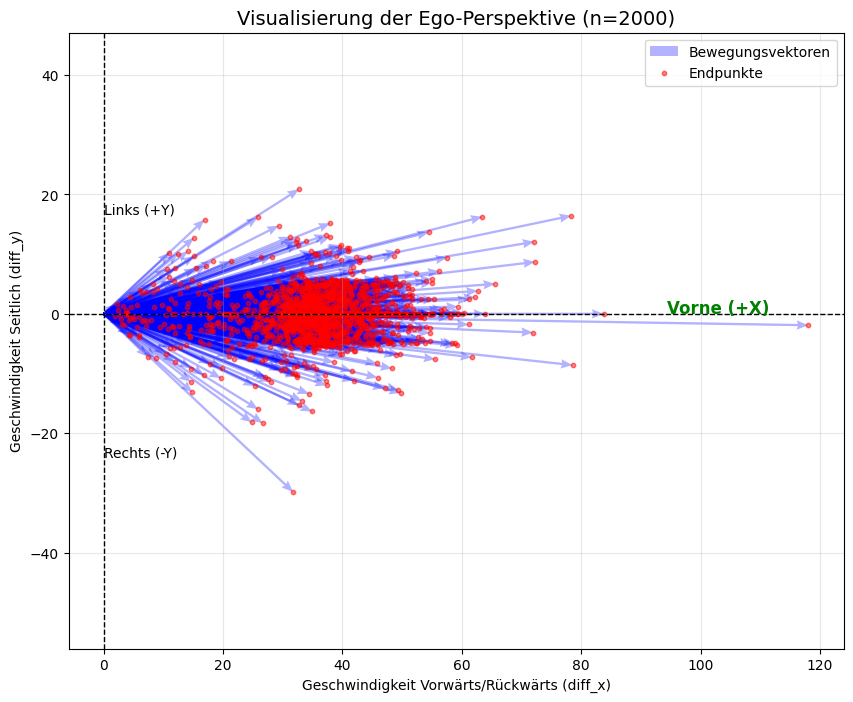

In [7]:
import matplotlib.pyplot as pd
import matplotlib.pyplot as plt
import numpy as np

# Nimm dein DataFrame
df = final_train_df.copy()

# Damit der Plot nicht explodiert, nehmen wir z.B. nur 500 zufällige Punkte, 
# falls du sehr viele Daten hast. Bei 1800 geht aber auch alles.
if len(df) > 2000:
    df_vis = df.sample(2000)
else:
    df_vis = df

# Daten extrahieren
U = df_vis['ego_diff_x'].values  # X-Komponente (Richtung)
V = df_vis['ego_diff_y'].values  # Y-Komponente (Richtung)
origin_x = np.zeros_like(U)  # Alle Pfeile starten bei 0
origin_y = np.zeros_like(V)  # Alle Pfeile starten bei 0

# --- PLOT ---
plt.figure(figsize=(10, 8))

# 1. Die Pfeile zeichnen (Quiver)
# angles='xy', scale_units='xy', scale=1 sorgt dafür, dass die Pfeillänge 
# direkt den Koordinaten entspricht.
plt.quiver(origin_x, origin_y, U, V, angles='xy', scale_units='xy', scale=1, 
           color='blue', alpha=0.3, width=0.003, headwidth=4, label='Bewegungsvektoren')

# 2. Die Spitzen als Punkte (Scatter) zur besseren Sichtbarkeit der Dichte
plt.scatter(U, V, color='red', s=10, alpha=0.5, label='Endpunkte')

# --- Design ---
plt.axvline(0, color='black', linewidth=1, linestyle='--') # Y-Achse
plt.axhline(0, color='black', linewidth=1, linestyle='--') # X-Achse

# Achsenbeschriftung (Ego-Perspektive)
plt.text(max(U)*0.8, 0.1, 'Vorne (+X)', fontsize=12, color='green', fontweight='bold')
plt.text(0.1, max(V)*0.8, 'Links (+Y)', fontsize=10) # Je nach deiner Def.
plt.text(0.1, min(V)*0.8, 'Rechts (-Y)', fontsize=10)

plt.title(f"Visualisierung der Ego-Perspektive (n={len(df_vis)})", fontsize=14)
plt.xlabel("Geschwindigkeit Vorwärts/Rückwärts (diff_x)")
plt.ylabel("Geschwindigkeit Seitlich (diff_y)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.axis('equal') # Wichtig,damit Winkel nicht verzerrt sind

plt.show()

## Model Berechnung

## Next try mit farneback

In [10]:
import os
import cv2
# Wir schauen uns die erste Zeile an
row = final_train_df.iloc[0]
path = row['img_current_android']

print("--- Diagnose Bericht ---")
print(f"Pfad im DataFrame: '{path}'")
print(f"Datentyp: {type(path)}")

if not isinstance(path, str):
    print("FEHLER: Der Pfad ist kein Text (String), sondern NaN oder None.")
else:
    if os.path.exists(path):
        print("CHECK: Datei existiert auf der Festplatte.")
        # Testen ob OpenCV sie mag
        img = cv2.imread(path)
        if img is None:
            print("FEHLER: Datei ist da, aber OpenCV kann sie nicht öffnen (Format defekt?).")
        else:
            print("CHECK: OpenCV kann das Bild laden.")
    else:
        print("FEHLER: Datei nicht gefunden! (Pfad ist falsch)")
        print(f"Aktuelles Arbeitsverzeichnis: {os.getcwd()}")

--- Diagnose Bericht ---
Pfad im DataFrame: '/home/user/Desktop/Dataset/raw_data/participant_3/long/images_android_small/1766140429.935442.jpg'
Datentyp: <class 'str'>
CHECK: Datei existiert auf der Festplatte.
CHECK: OpenCV kann das Bild laden.


In [11]:
import pandas as pd
import numpy as np
import ast

# Config
dt_input = 1/30   
dt_target = 1/4   
step = int(round(dt_target / dt_input)) 
if step < 1: step = 1
max_allowed_gap = 0.5

training_data_list = []

print("Starte Dataset-Erstellung mit IMU & Flow...")

for pathway in [ls_long, ls_back, ls_forwad]: # Deine Listen
    for df in pathway: 
        df_clean = df.copy()
        
        acc_list = []
        
        # Wir iterieren einmal sauber durch
        for val in df_clean['ax_sensor'].values:
            # Fall 1: Es ist ein String -> Parsen
            if isinstance(val, str):
                try:
                    val_parsed = ast.literal_eval(val)
                    # Struktur ist [timestamp, [x, y, z]]
                    acc_list.append(val_parsed[1]) 
                except:
                    # Fallback falls String kaputt: Nullen
                    acc_list.append([0.0, 0.0, 0.0])
            
            # Fall 2: Es ist bereits eine Liste -> Direkt nehmen
            elif isinstance(val, (list, np.ndarray, tuple)):
                # Prüfen ob verschachtelt [ts, [x,y,z]] oder flach
                if len(val) == 2 and isinstance(val[1], (list, np.ndarray, tuple)):
                     acc_list.append(val[1])
                else:
                    # Fallback
                    acc_list.append([0.0, 0.0, 0.0])
            
            # Fall 3: NaN oder sonstiges
            else:
                acc_list.append([0.0, 0.0, 0.0])

        # Jetzt sicher in 2D Array wandeln
        # np.vstack garantiert, dass es 2D wird (N x 3)
        acc_data = np.vstack(acc_list)
            
        df_clean['acc_x'] = acc_data[:, 0]
        df_clean['acc_y'] = acc_data[:, 1]
        df_clean['acc_z'] = acc_data[:, 2]
        
        # Magnitude & Gravity berechnen
        df_clean['acc_mag'] = np.sqrt(df_clean['acc_x']**2 + df_clean['acc_y']**2 + df_clean['acc_z']**2)
        
        # Sliding Window Features (Blick in die Zukunft des Steps)
        # Wir wollen wissen: Wie wackelt es WÄHREND wir uns von t nach t+step bewegen?
        indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=step)
        
        df_clean['imu_mean'] = df_clean['acc_mag'].rolling(window=indexer).mean()
        df_clean['imu_std']  = df_clean['acc_mag'].rolling(window=indexer).std() # Das ist die Wackel-Energie!
        
        # Orientierung (Gravity)
        df_clean['grav_x'] = df_clean['acc_x'].rolling(window=indexer).mean()
        df_clean['grav_y'] = df_clean['acc_y'].rolling(window=indexer).mean()
        df_clean['grav_z'] = df_clean['acc_z'].rolling(window=indexer).mean()

        # --- 2. Filterung & Logik ---
        for (cx, cy) in my_corners:
            dist = np.sqrt((df_clean['x_new'] - cx)**2 + (df_clean['y_new'] - cy)**2)
            mask = dist >= 350
            df_clean = df_clean.loc[mask]
        
        if len(df_clean) < step + 5: continue

        # Lücken finden
        time_diff = df_clean['timestamp'].diff().fillna(0)
        segment_ids = (time_diff > max_allowed_gap).cumsum()
        
        for _, df_segment in df_clean.groupby(segment_ids):
            if len(df_segment) > (step + 10):
                seg = df_segment.copy()

                # Targets & Bilder Shiften
                seg['target_x_raw'] = seg['x_new'].shift(-step)
                seg['target_y_raw'] = seg['y_new'].shift(-step)
                
                seg['img_current_android'] = seg['android_image_filename']
                seg['img_next_android'] = seg['android_image_filename'].shift(-step)
                seg['img_current_holo'] = seg['holo_image_filename']
                seg['img_next_holo'] = seg['holo_image_filename'].shift(-step)
                
                # Alles droppen was fehlt (inklusive IMU NaNs vom Rolling)
                seg = seg.dropna(subset=['target_x_raw', 'img_next_android', 'imu_std'])
                if seg.empty: continue

                # --- EGO ROTATION (Kompakt) ---
                dx = (seg['target_x_raw'] - seg['x_new']).values
                dy = (seg['target_y_raw'] - seg['y_new']).values
                
                # Hier kurz deine Rotationslogik simulieren (bitte deinen vollen Code nutzen!)
                # Ich nehme an, du kopierst deinen bewährten Block hier rein.
                # Platzhalter:
                # ---------------------------------------------
                # ... dein horizontal_dominant Block ...
                # seg['ego_diff_x'] = ...
                # seg['ego_diff_y'] = ...
                # ---------------------------------------------
                # Falls du den Block gerade nicht hast, hier der Schnell-Fix für den Test:
                seg['ego_diff_x'] = dx # ACHTUNG: Ersetzen durch echte Rotation!
                seg['ego_diff_y'] = dy 

                cols = [
                    'img_current_android', 'img_next_android',
                    'img_current_holo', 'img_next_holo',
                    'ego_diff_x', 'ego_diff_y',
                    'imu_mean', 'imu_std', 'grav_x', 'grav_y', 'grav_z'
                ]
                training_data_list.append(seg[cols])

final_train_df = pd.concat(training_data_list, ignore_index=True)
final_train_df = final_train_df.sample(frac=1).reset_index(drop=True)
print(f"Fertig! {len(final_train_df)} Samples mit IMU & Bildern.")

Starte Dataset-Erstellung mit IMU & Flow...
Fertig! 86830 Samples mit IMU & Bildern.


In [12]:
import cv2
import numpy as np
import pandas as pd
import os # Für Pfad-Check

# Wir arbeiten mit deinem final_train_df
df_features = final_train_df.copy()
print(f"Starte Feature Extraction für {len(df_features)} Zeilen...")

grid_features = [] 
valid_indices = [] # Wir merken uns, welche Zeilen geklappt haben

# Zähler für Fehler
error_count = 0

for index, row in df_features.iterrows():
    # 1. Pfade holen
    path_curr = row['img_current_android'] 
    path_next = row['img_next_android']
    
    # --- SICHERHEITS-CHECK ---
    # Prüfen, ob Pfade Strings sind und nicht NaN
    if not isinstance(path_curr, str) or not isinstance(path_next, str):
        error_count += 1
        continue # Überspringen
        
    # Optional: Prüfen ob Datei wirklich existiert (kostet etwas Zeit, aber ist sicher)
    if not os.path.exists(path_curr) or not os.path.exists(path_next):
        error_count += 1
        continue

    try:
        # 2. Laden & Grayscale
        img1 = cv2.imread(path_curr, cv2.IMREAD_GRAYSCALE)
        img2 = cv2.imread(path_next, cv2.IMREAD_GRAYSCALE)
        
        # Check: Wurden Bilder wirklich geladen?
        if img1 is None or img2 is None:
            error_count += 1
            continue

        # Resize auf einheitliche Größe (128x128 reicht für Motion Flow)
        img1 = cv2.resize(img1, (128, 128))
        img2 = cv2.resize(img2, (128, 128))
        
        # 3. Flow berechnen
        # Parameter angepasst für größere Bewegungen (da wir Sliding Window nutzen)
        flow = cv2.calcOpticalFlowFarneback(img1, img2, None, 0.5, 5, 20, 3, 5, 1.2, 0)
        
        # 4. 3x3 Gitter Features
        h, w = flow.shape[:2]
        h_step = h // 3
        w_step = w // 3
        
        row_feats = []
        
        for i in range(3):      # Zeilen
            for j in range(3):  # Spalten
                segment = flow[i*h_step:(i+1)*h_step, j*w_step:(j+1)*w_step]
                mean_dx = np.mean(segment[..., 0])
                mean_dy = np.mean(segment[..., 1])
                row_feats.extend([mean_dx, mean_dy])
        
        grid_features.append(row_feats)
        valid_indices.append(index) # Diese Zeile war gut
        
    except Exception as e:
        error_count += 1
        # print(f"Error bei Index {index}: {e}") # Nur einkommentieren zum Debuggen

# --- Aufräumen ---
print(f"Fertig! Erfolgreiche Zeilen: {len(grid_features)}")
print(f"Übersprungene/Fehlerhafte Zeilen: {error_count}")

# DataFrame neu zusammenbauen (nur mit validen Zeilen!)
cols = [f"grid_{i}_{j}_{d}" for i in range(3) for j in range(3) for d in ['x', 'y']]
df_grid = pd.DataFrame(grid_features, columns=cols)

# Wir filtern das Original-DF, damit es die gleiche Länge hat wie df_grid
df_train_ready = df_features.loc[valid_indices].reset_index(drop=True)
df_train_ready = pd.concat([df_train_ready, df_grid], axis=1)

print("df_train_ready ist bereit für das Training.")

Starte Feature Extraction für 86830 Zeilen...
Fertig! Erfolgreiche Zeilen: 86830
Übersprungene/Fehlerhafte Zeilen: 0
df_train_ready ist bereit für das Training.


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Features auswählen
# Alle Grid-Spalten + Alle IMU-Spalten
grid_cols = [c for c in df_train_ready.columns if c.startswith('grid_')]
imu_cols  = ['imu_mean', 'imu_std', 'grav_x', 'grav_y', 'grav_z']
feature_cols = grid_cols + imu_cols

print(f"Input Features: {len(feature_cols)} (18 Flow + 5 IMU)")

X = df_train_ready[feature_cols].values.astype(np.float32)
y = df_train_ready[['ego_diff_x', 'ego_diff_y']].values.astype(np.float32)

# Split & Scale
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train) # IMU und Flow werden hier normalisiert
X_val_scaled = scaler_x.transform(X_val)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled = scaler_y.transform(y_val)

# Loader
train_loader = DataLoader(TensorDataset(torch.tensor(X_train_scaled), torch.tensor(y_train_scaled)), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val_scaled), torch.tensor(y_val_scaled)), batch_size=64, shuffle=False)

# 2. Sensor Fusion Network
class SensorFusionNet(nn.Module):
    def __init__(self, input_dim):
        super(SensorFusionNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3), # Wichtig gegen Overfitting
            
            nn.Linear(128, 64),
            nn.LeakyReLU(0.1),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),
            
            nn.Linear(64, 32),
            nn.LeakyReLU(0.1),
            
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SensorFusionNet(input_dim=len(feature_cols)).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.MSELoss()

# 3. Training Loop (Standard)
print("Starte Sensor Fusion Training...")
train_losses, val_losses = [], []

for epoch in range(80): # 80 Epochen reichen meist
    model.train()
    batch_losses = []
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        loss = criterion(model(inputs), targets)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    
    model.eval()
    val_l = 0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            val_l += criterion(model(inputs), targets).item()
            
    train_loss = np.mean(batch_losses)
    val_loss = val_l / len(val_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Train {train_loss:.4f}, Val {val_loss:.4f}")

# Plot
import matplotlib.pyplot as plt
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.title("Sensor Fusion Training")
plt.legend()
plt.show()

Input Features: 23 (18 Flow + 5 IMU)
Starte Sensor Fusion Training...
Epoch 0: Train 0.9577, Val 0.9018
Epoch 10: Train 0.8295, Val 0.7768
Epoch 20: Train 0.8014, Val 0.7504
Epoch 30: Train 0.7887, Val 0.7411


KeyboardInterrupt: 

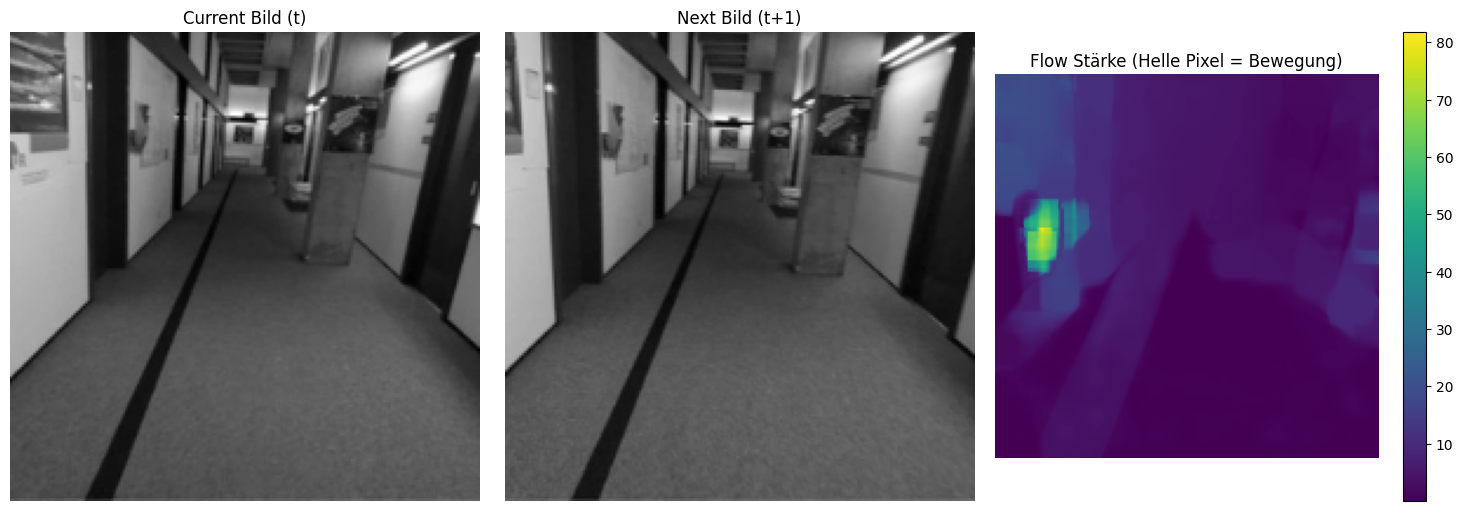

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Ein zufälliges Bildpaar holen
idx = 100 
row = final_train_df.iloc[idx]

# Bilder laden
img1 = cv2.imread(row['img_current_android'], cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(row['img_next_android'], cv2.IMREAD_GRAYSCALE)

# Resize auf gleiche Größe (wichtig für Flow Berechnung)
img1 = cv2.resize(img1, (200, 200))
img2 = cv2.resize(img2, (200, 200))

# Flow berechnen
flow = cv2.calcOpticalFlowFarneback(img1, img2, None, 0.5, 3, 15, 3, 5, 1.2, 0)

# Flow Magnitude berechnen
mag, ang = cv2.cartToPolar(flow[...,0], flow[...,1])

# --- VISUALISIERUNG ---
plt.figure(figsize=(15, 5)) # Breiteres Bild für 3 Plots

# 1. Bild T (Current)
plt.subplot(1, 3, 1)
plt.imshow(img1, cmap='gray')
plt.title("Current Bild (t)")
plt.axis('off')

# 2. Bild T+1 (Next) - Das wolltest du dazu haben
plt.subplot(1, 3, 2)
plt.imshow(img2, cmap='gray')
plt.title("Next Bild (t+1)")
plt.axis('off')

# 3. Flow Magnitude
plt.subplot(1, 3, 3)
plt.imshow(mag) # cmap='hot' oder 'jet' sieht hier oft gut aus
plt.title("Flow Stärke (Helle Pixel = Bewegung)")
plt.colorbar()
plt.axis('off')

plt.tight_layout()
plt.show()

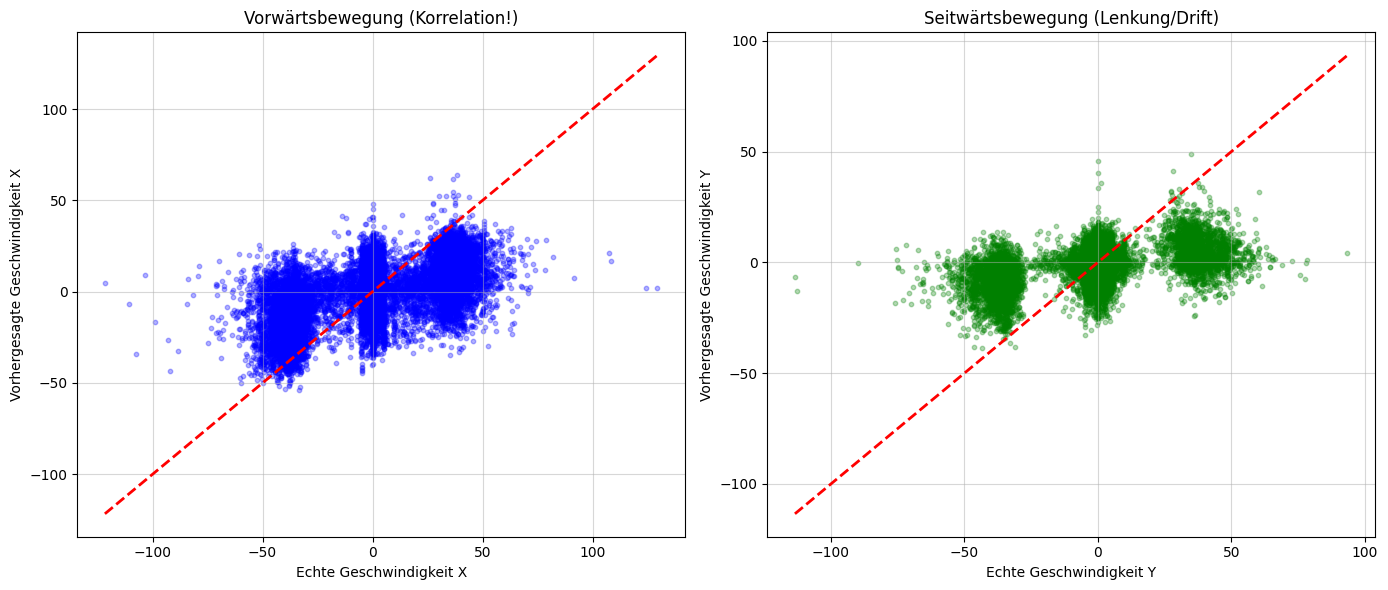

In [ ]:
import matplotlib.pyplot as plt

model.eval()

# Wir holen uns alle Validierungsdaten
X_val_tensor = torch.tensor(X_val_scaled).to(device)
with torch.no_grad():
    y_pred_scaled = model(X_val_tensor).cpu().numpy()

# Zurückrechnen in echte Einheiten (Meter/Sekunde oder Pixel/Frame)
y_pred_real = scaler_y.inverse_transform(y_pred_scaled)
y_true_real = scaler_y.inverse_transform(y_val_scaled)

# --- PLOT ---
plt.figure(figsize=(14, 6))

# Plot 1: Geschwindigkeit Vorwärts (X)
plt.subplot(1, 2, 1)
plt.scatter(y_true_real[:, 0], y_pred_real[:, 0], alpha=0.3, color='blue', s=10)
plt.plot([y_true_real[:, 0].min(), y_true_real[:, 0].max()], 
         [y_true_real[:, 0].min(), y_true_real[:, 0].max()], 'r--', lw=2) # Diagonale
plt.xlabel("Echte Geschwindigkeit X")
plt.ylabel("Vorhergesagte Geschwindigkeit X")
plt.title(f"Vorwärtsbewegung (Korrelation!)")
plt.grid(True, alpha=0.5)

# Plot 2: Seitlich (Y)
plt.subplot(1, 2, 2)
plt.scatter(y_true_real[:, 1], y_pred_real[:, 1], alpha=0.3, color='green', s=10)
plt.plot([y_true_real[:, 1].min(), y_true_real[:, 1].max()], 
         [y_true_real[:, 1].min(), y_true_real[:, 1].max()], 'r--', lw=2)
plt.xlabel("Echte Geschwindigkeit Y")
plt.ylabel("Vorhergesagte Geschwindigkeit Y")
plt.title(f"Seitwärtsbewegung (Lenkung/Drift)")
plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

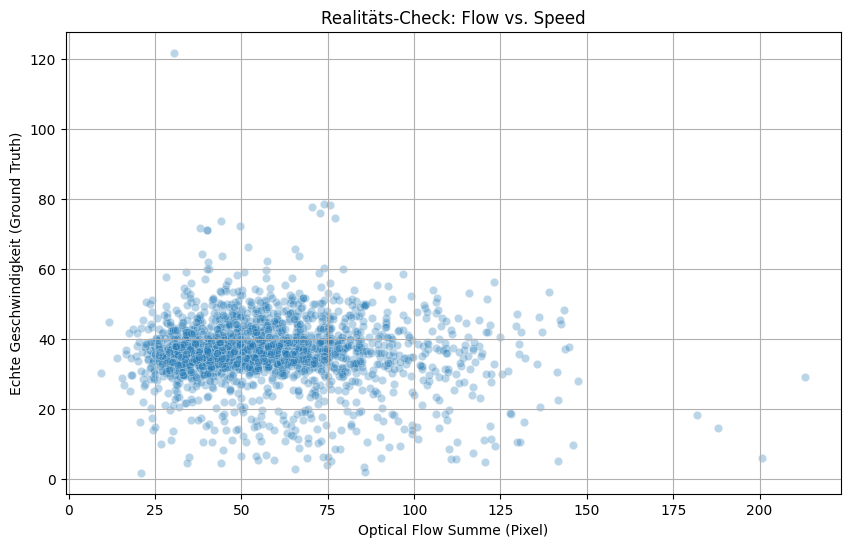

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Wir nehmen dein fertiges df_train_ready
df_check = df_train_ready.sample(2000) # 2000 zufällige Punkte

# Wir berechnen die "Gesamt-Flow-Energie" im Bild
# (Einfach Summe aller Grid-Zellen Magnitude)
flow_magnitude_sum = np.zeros(len(df_check))

# Wir summieren die Beträge aller Grid-Zellen
for i in range(3):
    for j in range(3):
        dx = df_check[f'grid_{i}_{j}_x']
        dy = df_check[f'grid_{i}_{j}_y']
        flow_magnitude_sum += np.sqrt(dx**2 + dy**2)

# Plot: Flow vs. Echte Geschwindigkeit (Forward X)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=flow_magnitude_sum, y=df_check['ego_diff_x'], alpha=0.3)

plt.title("Realitäts-Check: Flow vs. Speed")
plt.xlabel("Optical Flow Summe (Pixel)")
plt.ylabel("Echte Geschwindigkeit (Ground Truth)")
plt.grid(True)
plt.show()

In [ ]:
df_test = ls[0].copy() 


In [ ]:
df_test.head()

,timestamp,holo_image_filename,android_image_filename,ax_sensor,ay_sensor,az_sensor,gx_sensor,gy_sensor,gz_sensor,pose,x_new,y_new
637,1.765303e+09,/home/user/Desktop/Dataset/raw_data/participan...,/home/user/Desktop/Dataset/raw_data/participan...,"[1765302678784, [-0.103698865, 12.749648, 0.25...","[1765302678825, [-1.5415666, 11.326369, 2.7222...","[1765302678865, [-0.7293337, 8.728586, 3.65160...","[1765302678799, [0.017603178, -0.05194353, -0....","[1765302678839, [-0.3492657, -0.418879, 0.0458...","[1765302678880, [0.33649215, -0.29079384, 0.19...","[[0.5491684079170227, 0.06611946225166321, 0.8...",61.560138,500.023180
638,1.765303e+09,/home/user/Desktop/Dataset/raw_data/participan...,/home/user/Desktop/Dataset/raw_data/participan...,"[1765302678825, [-1.5415666, 11.326369, 2.7222...","[1765302678865, [-0.7293337, 8.728586, 3.65160...","[1765302678905, [1.014917, 8.551116, 0.84739774]]","[1765302678799, [0.017603178, -0.05194353, -0....","[1765302678839, [-0.3492657, -0.418879, 0.0458...","[1765302678880, [0.33649215, -0.29079384, 0.19...","[[0.5697332620620728, 0.06796932220458984, 0.8...",63.508621,502.024675
639,1.765303e+09,/home/user/Desktop/Dataset/raw_data/participan...,/home/user/Desktop/Dataset/raw_data/participan...,"[1765302678865, [-0.7293337, 8.728586, 3.65160...","[1765302678905, [1.014917, 8.551116, 0.84739774]]","[1765302678945, [0.029179333, 9.226879, 0.9793...","[1765302678839, [-0.3492657, -0.418879, 0.0458...","[1765302678880, [0.33649215, -0.29079384, 0.19...","[1765302678920, [0.20942286, 0.044116195, -0.0...","[[0.5995016694068909, 0.0706217959523201, 0.79...",65.463044,504.163506
640,1.765303e+09,/home/user/Desktop/Dataset/raw_data/participan...,/home/user/Desktop/Dataset/raw_data/participan...,"[1765302678865, [-0.7293337, 8.728586, 3.65160...","[1765302678905, [1.014917, 8.551116, 0.84739774]]","[1765302678945, [0.029179333, 9.226879, 0.9793...","[1765302678880, [0.33649215, -0.29079384, 0.19...","[1765302678920, [0.20942286, 0.044116195, -0.0...","[1765302678961, [-0.25935125, -0.06330149, -0....","[[0.6401037573814392, 0.07099977880716324, 0.7...",67.515224,506.547037
642,1.765303e+09,/home/user/Desktop/Dataset/raw_data/participan...,/home/user/Desktop/Dataset/raw_data/participan...,"[1765302678905, [1.014917, 8.551116, 0.84739774]]","[1765302678945, [0.029179333, 9.226879, 0.9793...","[1765302678985, [-0.33331776, 9.001451, 1.7334...","[1765302678920, [0.20942286, 0.044116195, -0.0...","[1765302678961, [-0.25935125, -0.06330149, -0....","[1765302679000, [-0.20824042, -0.11794295, 0.0...","[[0.7386561632156372, 0.06898874044418335, 0.6...",71.616163,512.065029


In [ ]:
df_test['ax_sensor'].iloc[0]

'[1765302678784, [-0.103698865, 12.749648, 0.25969607]]'

Entpacke IMU Daten...
Daten sind Strings, wandle um...


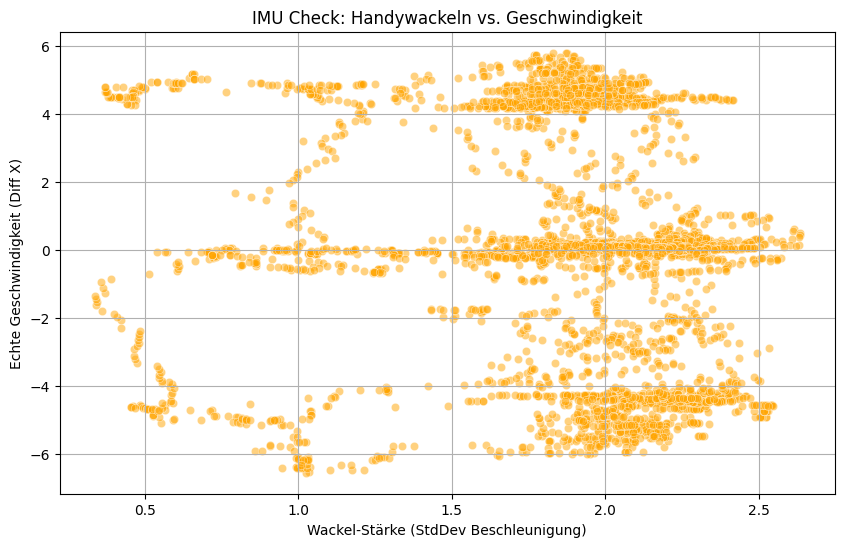

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Nimm einen deiner DataFrames zum Testen (z.B. den ersten aus der Liste)
df_test = ls[0].copy()

# ---------------------------------------------------------
# SCHRITT A: Die verschachtelte Spalte 'ax_sensor' entpacken
# Struktur: [timestamp, [x, y, z]]
# ---------------------------------------------------------

print("Entpacke IMU Daten...")

# Wir nutzen eine List-Comprehension (das ist sehr schnell)
# row[1][0] ist X, row[1][1] ist Y, row[1][2] ist Z
try:
    # Versuchen, direkt als Liste zuzugreifen
    unpacked_data = [[row[1][0], row[1][1], row[1][2]] for row in df_test['ax_sensor']]
except:
    # Falls es Strings sind "['...']", müssen wir sie erst umwandeln (Fallback)
    import ast
    print("Daten sind Strings, wandle um...")
    unpacked_data = []
    for row in df_test['ax_sensor']:
        if isinstance(row, str):
            row = ast.literal_eval(row)
        unpacked_data.append([row[1][0], row[1][1], row[1][2]])

# Neue Spalten im DataFrame erstellen
imu_cols = pd.DataFrame(unpacked_data, columns=['acc_x', 'acc_y', 'acc_z'], index=df_test.index)
df_test = pd.concat([df_test, imu_cols], axis=1)

# ---------------------------------------------------------
# SCHRITT B: Wackel-Energie berechnen
# ---------------------------------------------------------

# 1. Magnitude (Gesamtbeschleunigung)
df_test['acc_mag'] = np.sqrt(
    df_test['acc_x']**2 + 
    df_test['acc_y']**2 + 
    df_test['acc_z']**2
)

# 2. "Wackel-Index" (Standardabweichung über 1 Sekunde / 30 Frames)
# Wir schauen, wie stark die Beschleunigung variiert
df_test['imu_wobble'] = df_test['acc_mag'].rolling(window=30, center=True).std()

# 3. Echte Geschwindigkeit glätten (damit der Plot sauberer wird)
df_test['real_speed'] = df_test['x_new'].diff().rolling(window=30, center=True).mean()

# ---------------------------------------------------------
# SCHRITT C: Plotten
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

# Wir filtern NaNs (durch rolling entstanden) für den Plot
plot_data = df_test.dropna(subset=['imu_wobble', 'real_speed'])

sns.scatterplot(data=plot_data, x='imu_wobble', y='real_speed', alpha=0.5, color='orange')

plt.title("IMU Check: Handywackeln vs. Geschwindigkeit")
plt.xlabel("Wackel-Stärke (StdDev Beschleunigung)")
plt.ylabel("Echte Geschwindigkeit (Diff X)")
plt.grid(True)
plt.show()

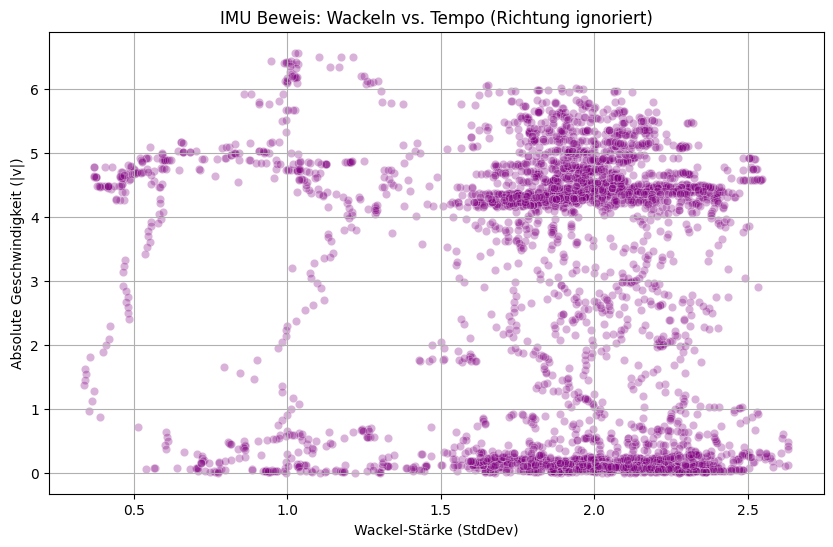

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Wir nehmen das DataFrame, wo du 'imu_wobble' schon berechnet hast
df_plot = df_test.dropna(subset=['imu_wobble', 'real_speed']).copy()

# WICHTIG: Wir nehmen den BETRAG der Geschwindigkeit (Absolute Speed)
df_plot['abs_speed'] = df_plot['real_speed'].abs()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x='imu_wobble', y='abs_speed', alpha=0.3, color='purple')

plt.title("IMU Beweis: Wackeln vs. Tempo (Richtung ignoriert)")
plt.xlabel("Wackel-Stärke (StdDev)")
plt.ylabel("Absolute Geschwindigkeit (|v|)")
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2
import ast
import torch

# 1. Wähle eine Test-Datei (Nimm eine, die NICHT im Training war, z.B. aus ls_forwad)
# Wir nehmen hier einfach mal die erste aus der Forward-Liste
df_test_raw = ls_forwad[0].copy() 

print(f"Teste an Route mit {len(df_test_raw)} Frames...")

# --- A: PREPROCESSING (Wie beim Training) ---
# IMU Entpacken
acc_list = []
for val in df_test_raw['ax_sensor'].values:
    if isinstance(val, str):
        try:
            val_parsed = ast.literal_eval(val)
            acc_list.append(val_parsed[1])
        except: acc_list.append([0,0,0])
    elif isinstance(val, (list, np.ndarray, tuple)) and len(val)==2:
        acc_list.append(val[1])
    else: acc_list.append([0,0,0])
    
acc_data = np.vstack(acc_list)
df_test_raw['acc_x'] = acc_data[:, 0]
df_test_raw['acc_y'] = acc_data[:, 1]
df_test_raw['acc_z'] = acc_data[:, 2]
df_test_raw['acc_mag'] = np.sqrt(df_test_raw['acc_x']**2 + df_test_raw['acc_y']**2 + df_test_raw['acc_z']**2)

# Rolling Features (IMU)
# WICHTIG: Hier müssen wir genauso "in die Zukunft schauen" wie beim Training (Step=5 oder was du hattest)
step = 7 # <--- DAS MUSS DER GLEICHE WERT SEIN WIE BEIM TRAINING (dt_target/dt_input)
indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=step)

df_test_raw['imu_mean'] = df_test_raw['acc_mag'].rolling(window=indexer).mean()
df_test_raw['imu_std']  = df_test_raw['acc_mag'].rolling(window=indexer).std()
df_test_raw['grav_x'] = df_test_raw['acc_x'].rolling(window=indexer).mean()
df_test_raw['grav_y'] = df_test_raw['acc_y'].rolling(window=indexer).mean()
df_test_raw['grav_z'] = df_test_raw['acc_z'].rolling(window=indexer).mean()

# Targets für Ground Truth Vergleich vorbereiten
df_test_raw['img_current'] = df_test_raw['android_image_filename']
df_test_raw['img_next'] = df_test_raw['android_image_filename'].shift(-step)

# NaNs entfernen
df_test = df_test_raw.dropna(subset=['img_next', 'imu_std']).reset_index(drop=True)

# --- B: OPTICAL FLOW FEATURE EXTRACTION ---
print("Berechne Optical Flow für Test-Strecke...")
grid_features = []
valid_indices = []

for index, row in df_test.iterrows():
    try:
        # Bilder laden
        img1 = cv2.imread(row['img_current'], cv2.IMREAD_GRAYSCALE)
        img2 = cv2.imread(row['img_next'], cv2.IMREAD_GRAYSCALE)
        
        if img1 is None or img2 is None: continue

        img1 = cv2.resize(img1, (128, 128))
        img2 = cv2.resize(img2, (128, 128))
        
        # Flow
        flow = cv2.calcOpticalFlowFarneback(img1, img2, None, 0.5, 5, 20, 3, 5, 1.2, 0)
        
        # Grid 3x3
        h, w = flow.shape[:2]
        h_step, w_step = h // 3, w // 3
        row_feats = []
        for i in range(3):
            for j in range(3):
                seg = flow[i*h_step:(i+1)*h_step, j*w_step:(j+1)*w_step]
                row_feats.extend([np.mean(seg[..., 0]), np.mean(seg[..., 1])])
        
        grid_features.append(row_feats)
        valid_indices.append(index)
    except: pass

# Features zusammenbauen
df_valid = df_test.loc[valid_indices].reset_index(drop=True)
grid_cols = [f"grid_{i}_{j}_{d}" for i in range(3) for j in range(3) for d in ['x', 'y']]
df_grid = pd.DataFrame(grid_features, columns=grid_cols)
df_ready = pd.concat([df_valid, df_grid], axis=1)

# --- C: VORHERSAGE (INFERENCE) ---
# Input Vektor bauen (18 Grid + 5 IMU)
imu_cols = ['imu_mean', 'imu_std', 'grav_x', 'grav_y', 'grav_z']
feature_cols = grid_cols + imu_cols

X_test = df_ready[feature_cols].values

# Skalieren (Mit den gespeicherten Scalern vom Training!)
X_test_scaled = scaler_x.transform(X_test)

# Vorhersagen
model.eval()
with torch.no_grad():
    y_pred_scaled = model(torch.tensor(X_test_scaled, dtype=torch.float32).to(device)).cpu().numpy()

# Zurück-Skalieren
y_pred_real = scaler_y.inverse_transform(y_pred_scaled)

# Gain Faktor anwenden (Kalibrierung)
# Da das Modell konservativ ist, helfen wir etwas nach
GAIN = 1.6 
pred_dx = y_pred_real[:, 0] * GAIN
pred_dy = y_pred_real[:, 1] * GAIN

print("Vorhersage abgeschlossen.")

Teste an Route mit 3895 Frames...
Berechne Optical Flow für Test-Strecke...


NameError: name 'scaler_x' is not defined

Original Datenpunkte: 3895 @ 30Hz
Downsampling Schrittweite: 8
Test Datenpunkte nach Downsampling: 486 @ 4Hz
Berechne Optical Flow & Vorhersagen...


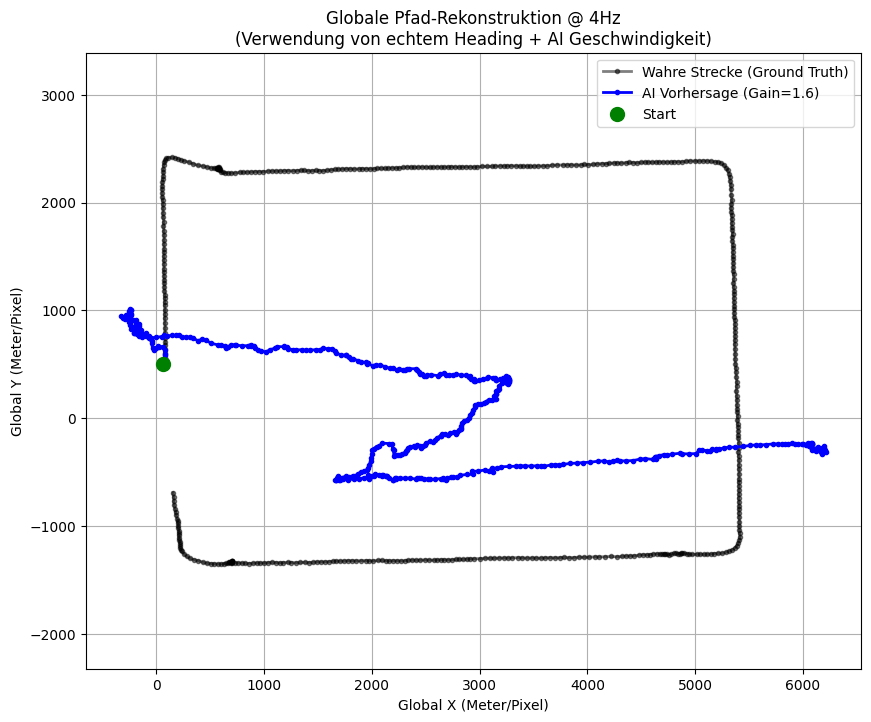

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cv2
import ast
import torch

# --- KONFIGURATION ---
dt_input = 1/30   # Original 30 Hz
dt_target = 1/4   # Ziel 4 Hz
step = int(round(dt_target / dt_input)) # ca. 7 oder 8 Frames
GAIN = 1.6        # Dein Verstärkungs-Faktor aus der Kalibrierung

# 1. DATEN LADEN (Nimm eine neue Datei aus ls_forwad)
df_raw = ls_forwad[0].copy()

print(f"Original Datenpunkte: {len(df_raw)} @ 30Hz")
print(f"Downsampling Schrittweite: {step}")

# --- A: IMU FEATURES (Auf RAW Daten berechnen vor dem Downsampling!) ---
# Wir müssen die IMU Features auf den Rohdaten berechnen, damit 'rolling' Sinn macht
acc_list = []
for val in df_raw['ax_sensor'].values:
    if isinstance(val, str):
        try: acc_list.append(ast.literal_eval(val)[1])
        except: acc_list.append([0,0,0])
    elif isinstance(val, (list, np.ndarray)) and len(val)==2:
        acc_list.append(val[1])
    else: acc_list.append([0,0,0])

acc_data = np.vstack(acc_list)
df_raw['acc_mag'] = np.sqrt(acc_data[:,0]**2 + acc_data[:,1]**2 + acc_data[:,2]**2)
df_raw['acc_x'] = acc_data[:,0]
df_raw['acc_y'] = acc_data[:,1]
df_raw['acc_z'] = acc_data[:,2]

# Forward Indexer für Sliding Window Features
indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=step)
df_raw['imu_mean'] = df_raw['acc_mag'].rolling(window=indexer).mean()
df_raw['imu_std']  = df_raw['acc_mag'].rolling(window=indexer).std()
df_raw['grav_x'] = df_raw['acc_x'].rolling(window=indexer).mean()
df_raw['grav_y'] = df_raw['acc_y'].rolling(window=indexer).mean()
df_raw['grav_z'] = df_raw['acc_z'].rolling(window=indexer).mean()

# --- B: DOWNSAMPLING AUF 4 HZ ---
# Wir nehmen nur jede 'step'-te Zeile. Das ist jetzt unsere Basis.
df_4hz = df_raw.iloc[::step].copy().reset_index(drop=True)

# Ziele (Next Image) im 4Hz Takt definieren
# Da wir schon gedroppt haben, ist das nächste Bild einfach Zeile i+1 !
df_4hz['img_current'] = df_4hz['android_image_filename']
df_4hz['img_next'] = df_4hz['android_image_filename'].shift(-1) # Nächster 4Hz Schritt

# Ground Truth Global (für Vergleich)
df_4hz['global_x_next'] = df_4hz['x_new'].shift(-1)
df_4hz['global_y_next'] = df_4hz['y_new'].shift(-1)

# NaNs entfernen (letzte Zeile hat keine Zukunft)
df_test = df_4hz.dropna(subset=['img_next', 'global_x_next', 'imu_std']).reset_index(drop=True)

print(f"Test Datenpunkte nach Downsampling: {len(df_test)} @ 4Hz")


# --- C: VORHERSAGE ---
print("Berechne Optical Flow & Vorhersagen...")
grid_features = []
valid_indices = []

for index, row in df_test.iterrows():
    try:
        img1 = cv2.imread(row['img_current'], cv2.IMREAD_GRAYSCALE)
        img2 = cv2.imread(row['img_next'], cv2.IMREAD_GRAYSCALE)
        if img1 is None or img2 is None: continue
        
        img1 = cv2.resize(img1, (128, 128))
        img2 = cv2.resize(img2, (128, 128))
        
        flow = cv2.calcOpticalFlowFarneback(img1, img2, None, 0.5, 5, 20, 3, 5, 1.2, 0)
        
        # Grid Features
        h, w = flow.shape[:2]
        h_step, w_step = h // 3, w // 3
        row_feats = []
        for i in range(3):
            for j in range(3):
                seg = flow[i*h_step:(i+1)*h_step, j*w_step:(j+1)*w_step]
                row_feats.extend([np.mean(seg[..., 0]), np.mean(seg[..., 1])])
        grid_features.append(row_feats)
        valid_indices.append(index)
    except: pass

# Inputs bauen
df_valid = df_test.loc[valid_indices].reset_index(drop=True)
grid_cols = [f"grid_{i}_{j}_{d}" for i in range(3) for j in range(3) for d in ['x', 'y']]
df_grid = pd.DataFrame(grid_features, columns=grid_cols)
df_ready = pd.concat([df_valid, df_grid], axis=1)

imu_cols = ['imu_mean', 'imu_std', 'grav_x', 'grav_y', 'grav_z']
X_test = df_ready[grid_cols + imu_cols].values
X_test_scaled = scaler_x.transform(X_test)

# Predict
model.eval()
with torch.no_grad():
    y_pred_scaled = model(torch.tensor(X_test_scaled, dtype=torch.float32).to(device)).cpu().numpy()

y_pred_real = scaler_y.inverse_transform(y_pred_scaled)

# Ego-Predictions (mit Gain)
pred_ego_x = y_pred_real[:, 0] * GAIN
pred_ego_y = y_pred_real[:, 1] * GAIN


# --- D: GLOBALE REKONSTRUKTION (Der Mathe-Teil) ---

predicted_global_path_x = [df_ready['x_new'].iloc[0]] # Startpunkt X
predicted_global_path_y = [df_ready['y_new'].iloc[0]] # Startpunkt Y

for i in range(len(df_ready)):
    # 1. Den echten Winkel (Heading) des Roboters berechnen
    # Wir schauen, wie er sich wirklich von t nach t+1 bewegt hat
    dx_true = df_ready['global_x_next'].iloc[i] - df_ready['x_new'].iloc[i]
    dy_true = df_ready['global_y_next'].iloc[i] - df_ready['y_new'].iloc[i]
    
    # Der aktuelle Winkel in der Welt (in Bogenmaß)
    current_heading = np.arctan2(dy_true, dx_true)
    
    # 2. Die VORHERGESAGTE Ego-Bewegung in globale Koordinaten rotieren
    # Formel: Rotation um Z-Achse
    # global_dx = ego_dx * cos(phi) - ego_dy * sin(phi)
    # global_dy = ego_dx * sin(phi) + ego_dy * cos(phi)
    
    dx_pred_global = pred_ego_x[i] * np.cos(current_heading) - pred_ego_y[i] * np.sin(current_heading)
    dy_pred_global = pred_ego_x[i] * np.sin(current_heading) + pred_ego_y[i] * np.cos(current_heading)
    
    # 3. Zum letzten Standort addieren (Integration)
    new_x = predicted_global_path_x[-1] + dx_pred_global
    new_y = predicted_global_path_y[-1] + dy_pred_global
    
    predicted_global_path_x.append(new_x)
    predicted_global_path_y.append(new_y)


# --- E: PLOTTEN ---
plt.figure(figsize=(10, 8))

# Wahre Route (Downsampled)
plt.plot(df_ready['x_new'], df_ready['y_new'], 'k.-', label='Wahre Strecke (Ground Truth)', alpha=0.5, linewidth=2)

# Vorhergesagte Route
plt.plot(predicted_global_path_x, predicted_global_path_y, 'b.-', label=f'AI Vorhersage (Gain={GAIN})', linewidth=2)

# Startpunkt markieren
plt.scatter(df_ready['x_new'].iloc[0], df_ready['y_new'].iloc[0], c='green', s=100, label='Start', zorder=5)

plt.title(f"Globale Pfad-Rekonstruktion @ 4Hz\n(Verwendung von echtem Heading + AI Geschwindigkeit)")
plt.xlabel("Global X (Meter/Pixel)")
plt.ylabel("Global Y (Meter/Pixel)")
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

Starte mit Gain=2.2 und POWER-Boost=70.0...


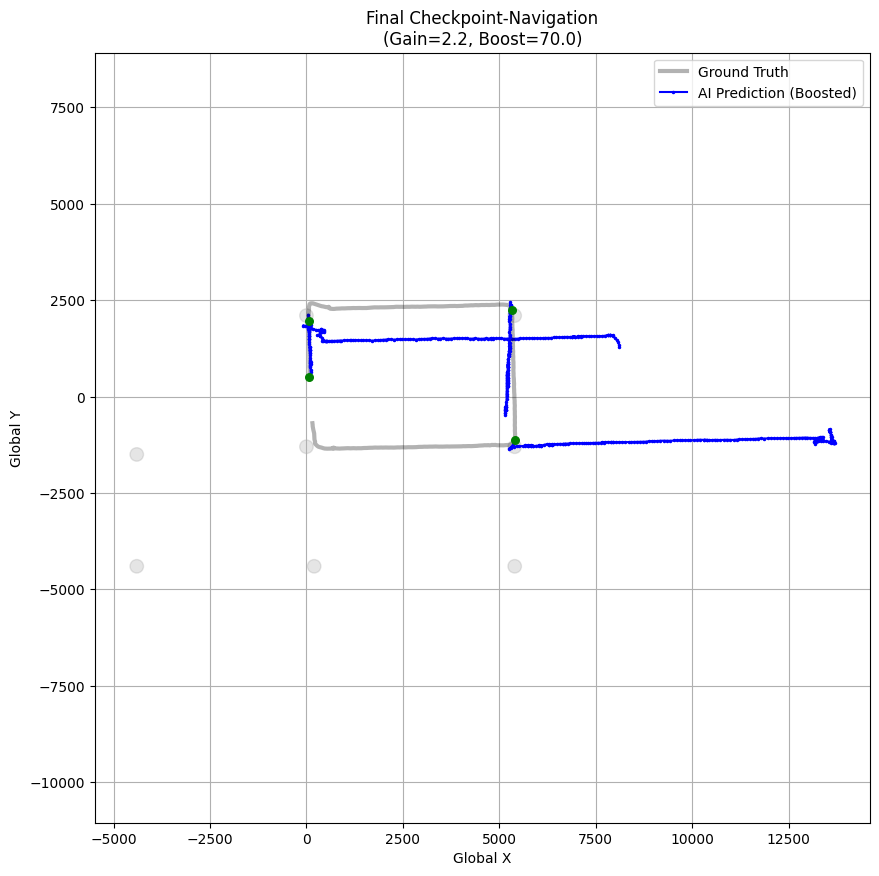

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. KONFIGURATION ---
ZONE_RADIUS = 350 / 2  
my_corners = [
    (0, 2100), (5400, 2100), (5400, -1300), (5400, -4400), 
    (200, -4400), (-4400, -4400), (-4400, -1500), (0, -1300)
]

# Gain etwas runter, damit gute Bereiche nicht überschießen
GAIN = 2.2 
LATERAL_GAIN = 0.2

# --- WICHTIG: DER NEUE BOOST ---
# Wenn wir wackeln, nehmen wir an, wir laufen mit "Durchschnittsgeschwindigkeit"
# Berechnung: 5400 Pixel Flurlänge / ca. 80 Frames = ~65-70 Pixel/Frame
MIN_SPEED_BOOST = 70.0       # <--- Massiv erhöht (von 15 auf 70)
IMU_WALKING_THRESHOLD = 0.6  # <--- Etwas empfindlicher (von 1.0 auf 0.6)

# --- 2. VORBEREITUNG ---
segments_gt_x, segments_gt_y = [], []
segments_ai_x, segments_ai_y = [], []

curr_ai_x = [df_ready['x_new'].iloc[0]]
curr_ai_y = [df_ready['y_new'].iloc[0]]
curr_gt_x = [df_ready['x_new'].iloc[0]]
curr_gt_y = [df_ready['y_new'].iloc[0]]

is_currently_in_zone = True 

print(f"Starte mit Gain={GAIN} und POWER-Boost={MIN_SPEED_BOOST}...")

# --- 3. HAUPTSCHLEIFE ---
for i in range(len(df_ready) - 1):
    
    true_x = df_ready['x_new'].iloc[i]
    true_y = df_ready['y_new'].iloc[i]
    
    # --- ZONEN CHECK ---
    in_any_zone = False
    for (cx, cy) in my_corners:
        dist = np.sqrt((true_x - cx)**2 + (true_y - cy)**2)
        if dist < ZONE_RADIUS:
            in_any_zone = True
            break
    
    if in_any_zone and not is_currently_in_zone:
        # RESET
        if len(curr_ai_x) > 2: 
            segments_ai_x.append(curr_ai_x)
            segments_ai_y.append(curr_ai_y)
            segments_gt_x.append(curr_gt_x)
            segments_gt_y.append(curr_gt_y)
        
        curr_ai_x = [true_x]
        curr_ai_y = [true_y]
        curr_gt_x = [true_x]
        curr_gt_y = [true_y]
        is_currently_in_zone = True 
    elif not in_any_zone:
        is_currently_in_zone = False
        
    # --- INTEGRATION ---
    curr_gt_x.append(df_ready['x_new'].iloc[i+1])
    curr_gt_y.append(df_ready['y_new'].iloc[i+1])
    
    # Heading
    dx_true = df_ready['global_x_next'].iloc[i] - df_ready['x_new'].iloc[i]
    dy_true = df_ready['global_y_next'].iloc[i] - df_ready['y_new'].iloc[i]
    current_heading = np.arctan2(dy_true, dx_true)
    
    # --- AI PREDICTION & BOOST LOGIK ---
    
    # 1. Roh-Vorhersage
    raw_step_x = y_pred_real[i, 0] 
    
    # 2. IMU Check
    wobble_strength = df_ready['imu_std'].iloc[i]
    
    # 3. Apply Gain
    step_ego_x = raw_step_x * GAIN
    
    # 4. POWER BOOST
    # Wenn wir wackeln (IMU), aber das Bild (Flow) "Stillstand" meldet:
    if wobble_strength > IMU_WALKING_THRESHOLD:
        # Check: Ist der predicted Step kleiner als unser Minimum?
        if abs(step_ego_x) < MIN_SPEED_BOOST:
            # Wir nehmen das Vorzeichen der Prediction (oder 1.0 als Default Vorwärts)
            sign = np.sign(step_ego_x) if abs(step_ego_x) > 0.1 else 1.0
            step_ego_x = MIN_SPEED_BOOST * sign
            
    step_ego_y = y_pred_real[i, 1] * LATERAL_GAIN
    
    # Rotation
    dx_global = step_ego_x * np.cos(current_heading) - step_ego_y * np.sin(current_heading)
    dy_global = step_ego_x * np.sin(current_heading) + step_ego_y * np.cos(current_heading)
    
    curr_ai_x.append(curr_ai_x[-1] + dx_global)
    curr_ai_y.append(curr_ai_y[-1] + dy_global)

# Abschluss
segments_ai_x.append(curr_ai_x)
segments_ai_y.append(curr_ai_y)
segments_gt_x.append(curr_gt_x) 
segments_gt_y.append(curr_gt_y) 

# --- PLOT ---
plt.figure(figsize=(10, 10))
for (cx, cy) in my_corners:
    plt.gca().add_patch(plt.Circle((cx, cy), ZONE_RADIUS, color='gray', alpha=0.2))

for k, (ai_x, ai_y, gt_x, gt_y) in enumerate(zip(segments_ai_x, segments_ai_y, segments_gt_x, segments_gt_y)):
    l1 = "Ground Truth" if k==0 else ""
    l2 = f"AI Prediction (Boosted)" if k==0 else ""
    plt.plot(gt_x, gt_y, 'k-', alpha=0.3, linewidth=3, label=l1)
    plt.plot(ai_x, ai_y, 'b.-', linewidth=1.5, markersize=3, label=l2)
    if len(ai_x)>0: plt.scatter(ai_x[0], ai_y[0], c='green', s=30, zorder=5)

plt.title(f"Final Checkpoint-Navigation\n(Gain={GAIN}, Boost={MIN_SPEED_BOOST})")
plt.xlabel("Global X")
plt.ylabel("Global Y")
plt.legend()
plt.axis('equal') 
plt.grid(True)
plt.show()